# Hedge Algebra trên final_data.csv
Triển khai HA-FCM (2010), HABR-SIG/HABR-MUL (2019) và mô hình luật mờ từ `docs/Fuzzy_Classification_Hedge_Algebra_Clickstream.docx`. Mỗi mô hình được đánh giá bằng `classification_report` và `confusion_matrix` như `modeling.ipynb`.

Đây là áp dụng thuật toán lên OULAD, không phải tái lập các bảng thực nghiệm Iris/KEEL. Chia 80/20 như notebook mẫu; 20% của phần train làm validation. Tối ưu trên validation, test chỉ đánh giá cuối cùng. Dữ liệu toàn khóa có average_score và has_unregistered: kết quả là phân loại cuối khóa, không phải dự báo sớm.

Nguồn đối chiếu công thức HA-FCM/HABR: [HA-FCM](https://doi.org/10.1145/1852611.1852621), [HABR](https://vjs.ac.vn/jcc/article/download/14348/383257/394092). Mô hình luật mờ cuối notebook dùng 5 mức ngôn ngữ và luồng xử lý trong DOCX; các tâm ngữ nghĩa được tính từ tham số Hedge Algebra thay vì gán cách đều.

Điều chỉnh để chạy trên OULAD: thuộc tính danh nghĩa dùng điều kiện bằng nhau; IFRG sinh luật bằng beam search thay vì vét cạn mọi tổ hợp; ngân sách GA/MOPSO mặc định nhỏ hơn bài báo. Mô hình theo DOCX chỉ dùng các cột lượt click vì dữ liệu không có thời gian học hay điểm quiz riêng. Các điều chỉnh này không được xem là tái lập nguyên vẹn thực nghiệm bài báo.

In [1]:
from pathlib import Path
from itertools import combinations
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from scipy.spatial.distance import cdist

SEED = 42
# Ngân sách tính toán; bài 2019 dùng 600 particles, 250/1000 generations.
GA_POP, GA_GEN = 12, 8
PSO_POP, SEM_GEN, RULE_GEN = 10, 8, 12
MAX_ITER, TOL = 150, 1e-5
BEAM_PER_CLASS, RULES_PER_CLASS, MAX_RULE_LENGTH = 30, 300, 3
rng = np.random.default_rng(SEED)


In [2]:
DATA_PATH = Path('final_data.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError('Chạy notebook trong thư mục chứa final_data.csv.')
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
assert {'id_student', 'final_result'}.issubset(df.columns)
df = df.dropna(subset=['final_result']).reset_index(drop=True)
X = df.drop(columns=['id_student', 'final_result'])
encoder = LabelEncoder()
y = encoder.fit_transform(df['final_result'])
target_names = encoder.classes_.astype(str)
labels = np.arange(len(target_names))
train_idx, test_idx = train_test_split(np.arange(len(df)), test_size=0.2,
                                      random_state=SEED, stratify=y)
fit_idx, val_idx = train_test_split(train_idx, test_size=0.2,
                                    random_state=SEED, stratify=y[train_idx])
assert not set(train_idx) & set(test_idx)
assert not set(fit_idx) & set(val_idx)
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]
print('Dữ liệu:', df.shape, '| Train/validation/test:', len(fit_idx), len(val_idx), len(test_idx))
display(pd.Series(df['final_result'].value_counts(), name='Số mẫu'))

# Fit preprocessing riêng cho giai đoạn tuning và refit cuối cùng.
def make_preprocessor():
    return ColumnTransformer([
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                          ('scale', MinMaxScaler(clip=True))]), num_cols),
        ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                          ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
    ], sparse_threshold=0)

def prepare(train, other):
    prep = make_preprocessor()
    a = prep.fit_transform(X.iloc[train])
    b = prep.transform(X.iloc[other])
    assert np.isfinite(a).all() and np.isfinite(b).all()
    return prep, a, b

prep_tune, A_fit, A_val = prepare(fit_idx, val_idx)
prep_final, A_train, A_test = prepare(train_idx, test_idx)
results, predictions = [], {}

def evaluate(name, pred):
    predictions[name] = np.asarray(pred)
    print('\nModel:', name)
    print(classification_report(y[test_idx], pred, labels=labels,
                                target_names=target_names, zero_division=0))
    cm = confusion_matrix(y[test_idx], pred, labels=labels)
    assert cm.sum() == len(test_idx)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix: ' + name)
    plt.xlabel('Predicted Labels'); plt.ylabel('True Labels')
    plt.tight_layout(); plt.show()
    results.append({'Model': name, 'Accuracy': accuracy_score(y[test_idx], pred),
                    'Macro F1': f1_score(y[test_idx], pred, average='macro', zero_division=0),
                    'Weighted F1': f1_score(y[test_idx], pred, average='weighted', zero_division=0)})


Dữ liệu: (32593, 19) | Train/validation/test: 20859 5215 6519


final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: Số mẫu, dtype: int64

## 1. K-means, FCM và HA-FCM theo bài báo 1852611.1852621

Bài báo dùng K-means để khởi tạo tâm HA-FCM, chia bán kính cụm thành các khoảng ngôn ngữ Hedge Algebra, lấy độ mờ của khoảng làm trọng số khoảng cách rồi cập nhật membership và tâm theo FCM. HA-FCM chỉ đưa mẫu có membership ≥ ngưỡng trung hòa `w` vào bước cập nhật tâm; GA chọn `w`, bốn độ đo hedge và hệ số mờ `m` bằng tập validation.

Áp dụng cho OULAD: dùng cùng các thuộc tính **số** đã chuẩn hóa cho cả ba thuật toán (bài báo thử trên dữ liệu Iris dạng số). One-hot của các thuộc tính danh mục từng chiếm khoảng 93% khoảng cách và che lấp tín hiệu số. Bán kính `dmax` được tính từ mẫu thuộc từng cụm trên train và giữ cố định khi dự đoán test. Dùng đúng 4 cụm như 4 lớp. Để đối chiếu cụm không nhãn với nhãn thật, tìm phép ghép một-một giữa 4 cụm và 4 lớp trên train bằng Hungarian, tối đa hóa tổng recall theo lớp; không dùng nhãn test. GA tối ưu macro F1 trên validation thay vì accuracy để không bỏ qua lớp ít mẫu. Đây là các lựa chọn đánh giá khi đưa thuật toán phân cụm của bài báo vào bài toán 4 lớp, không thay đổi công thức HA-FCM.

Các cột `average_score` và `has_unregistered` phản ánh thông tin cuối khóa. Vì chúng vẫn nằm trong các thuộc tính số, kết quả ở mục này là **phân loại cuối khóa**, không phải dự báo sớm.

GA 1/8: validation macro F1=0.7051
GA 2/8: validation macro F1=0.7051
GA 3/8: validation macro F1=0.7051
GA 4/8: validation macro F1=0.7217
GA 5/8: validation macro F1=0.7217
GA 6/8: validation macro F1=0.7217
GA 7/8: validation macro F1=0.7217
GA 8/8: validation macro F1=0.7395

K-means: thành phần các cụm trên train


,Gán nhãn,Distinction,Fail,Pass,Withdrawn
0,Distinction,2304,376,6083,0
1,Fail,0,3453,38,76
2,Withdrawn,0,8,0,8047
3,Pass,115,1804,3768,2


Số dự đoán theo lớp: {np.str_('Distinction'): np.int64(2156), np.str_('Fail'): np.int64(899), np.str_('Pass'): np.int64(1447), np.str_('Withdrawn'): np.int64(2017)}

Model: K-means
              precision    recall  f1-score   support

 Distinction       0.27      0.95      0.42       605
        Fail       0.97      0.62      0.76      1411
        Pass       0.67      0.39      0.49      2472
   Withdrawn       1.00      0.99      1.00      2031

    accuracy                           0.68      6519
   macro avg       0.73      0.74      0.67      6519
weighted avg       0.80      0.68      0.70      6519



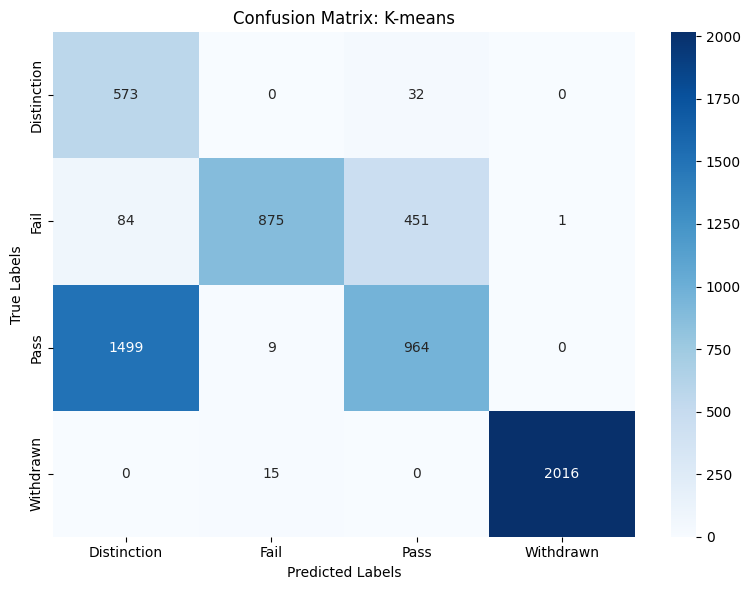


FCM: thành phần các cụm trên train


,Gán nhãn,Distinction,Fail,Pass,Withdrawn
0,Distinction,2271,304,5371,0
1,Fail,0,3603,58,76
2,Withdrawn,0,8,0,8047
3,Pass,148,1726,4460,2


Số dự đoán theo lớp: {np.str_('Distinction'): np.int64(1984), np.str_('Fail'): np.int64(942), np.str_('Pass'): np.int64(1576), np.str_('Withdrawn'): np.int64(2017)}

Model: FCM
              precision    recall  f1-score   support

 Distinction       0.28      0.93      0.43       605
        Fail       0.97      0.65      0.77      1411
        Pass       0.70      0.45      0.55      2472
   Withdrawn       1.00      0.99      1.00      2031

    accuracy                           0.71      6519
   macro avg       0.74      0.75      0.69      6519
weighted avg       0.81      0.71      0.73      6519



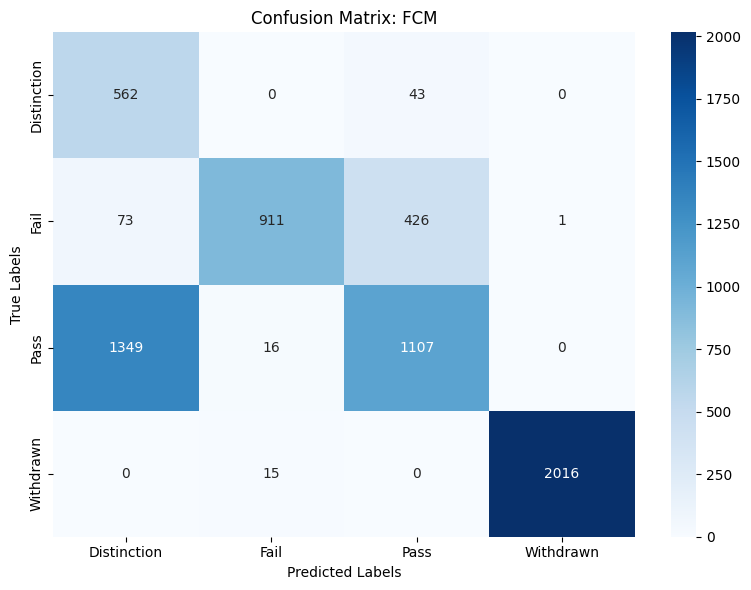


HA-FCM: thành phần các cụm trên train


,Gán nhãn,Distinction,Fail,Pass,Withdrawn
0,Distinction,1089,39,1413,0
1,Fail,0,3443,40,76
2,Withdrawn,0,8,0,8047
3,Pass,1330,2151,8436,2


Số dự đoán theo lớp: {np.str_('Distinction'): np.int64(606), np.str_('Fail'): np.int64(901), np.str_('Pass'): np.int64(2995), np.str_('Withdrawn'): np.int64(2017)}

Model: HA-FCM
              precision    recall  f1-score   support

 Distinction       0.42      0.42      0.42       605
        Fail       0.97      0.62      0.76      1411
        Pass       0.71      0.86      0.78      2472
   Withdrawn       1.00      0.99      1.00      2031

    accuracy                           0.81      6519
   macro avg       0.78      0.72      0.74      6519
weighted avg       0.83      0.81      0.81      6519



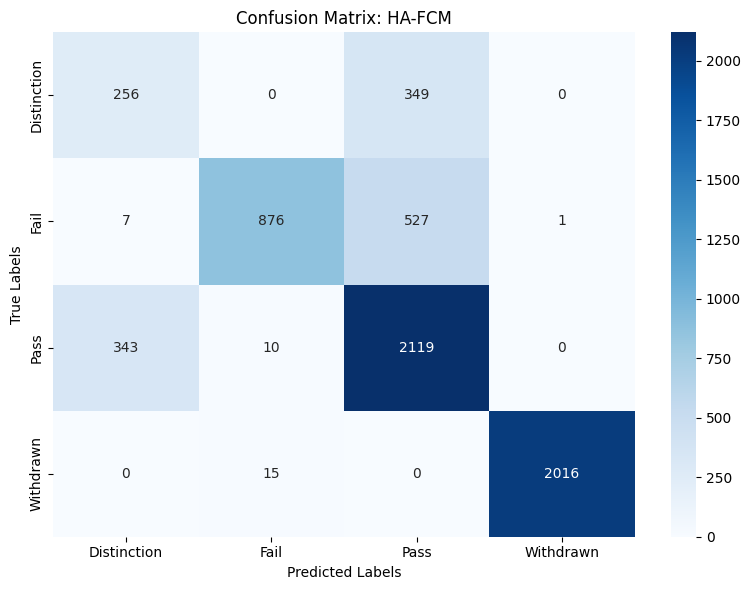

HA-FCM đã chọn: {'m': np.float64(2.396296497728873), 'ha': True, 'w': np.float64(0.5914985250796758), 'mu': array([0.1774844 , 0.22991548, 0.3001346 , 0.29246553])} | validation macro F1: 0.73951243142676


In [3]:
from scipy.optimize import linear_sum_assignment

# Giữ cùng không gian số cho K-means, FCM và HA-FCM.
cluster_cols = num_cols.copy()
Z_fit, Z_val = A_fit[:, :len(cluster_cols)], A_val[:, :len(cluster_cols)]
Z_train, Z_test = A_train[:, :len(cluster_cols)], A_test[:, :len(cluster_cols)]


class FuzzyCMeans:
    def __init__(self, n_clusters, m=2., ha=False, w=.5, mu=None):
        self.n_clusters, self.m, self.ha, self.w = n_clusters, m, ha, w
        self.mu = np.asarray(mu if mu is not None else [.25]*4, dtype=float)
        self.mu /= self.mu.sum()  # L, P, M, V
        assert m > 1 and 0 < w < 1 and np.all(self.mu > 0)
        L, P, M, V = self.mu
        self.widths = np.array([V*w, M*w, P*w, L*w,
                                L*(1-w), P*(1-w), M*(1-w), V*(1-w)])
        self.edges = np.cumsum(self.widths)

    @staticmethod
    def cluster_radii(X, centers, assignment):
        distances = cdist(X, centers)
        return np.array([distances[assignment == j, j].max()
                         if np.any(assignment == j) else distances[:, j].max()
                         for j in range(len(centers))])

    def memberships(self, X, centers, radii):
        d = cdist(X, centers)
        if self.ha:
            r = np.clip(1 - d / np.maximum(radii, 1e-12), 0, 1)
            ix = np.clip(np.searchsorted(self.edges, r, side='right'), 0, 7)
            effective = self.widths[ix] * d
        else:
            effective = d
        log_u = -2 / (self.m - 1) * np.log(np.maximum(effective, 1e-12))
        log_u -= log_u.max(axis=1, keepdims=True)
        u = np.exp(log_u)
        u /= u.sum(axis=1, keepdims=True)
        zero = d <= 1e-12
        rows = zero.any(axis=1)
        u[rows] = zero[rows] / zero[rows].sum(axis=1, keepdims=True)
        return u

    def fit(self, X):
        initial = KMeans(self.n_clusters, n_init=10, random_state=SEED).fit(X)
        centers = initial.cluster_centers_
        assignment = initial.labels_
        for iteration in range(MAX_ITER):
            radii = self.cluster_radii(X, centers, assignment)
            u = self.memberships(X, centers, radii)
            weights = u ** self.m
            if self.ha:
                weights *= u >= self.w
            mass = weights.sum(axis=0)
            new = centers.copy()
            valid = mass > 1e-12
            new[valid] = (weights[:, valid].T @ X) / mass[valid, None]
            movement = np.linalg.norm(new - centers, axis=1).max()
            centers = new
            assignment = u.argmax(axis=1)
            if movement < TOL:
                break
        self.centers_ = centers
        self.radii_ = self.cluster_radii(X, centers, assignment)
        self.n_iter_ = iteration + 1
        return self

    def predict(self, X):
        return self.memberships(X, self.centers_, self.radii_).argmax(axis=1)


def cluster_map(model, data, truth):
    """One-to-one cluster-to-class alignment using only labeled training data."""
    if model.n_clusters != len(labels):
        raise ValueError('Phép ghép một-một yêu cầu số cụm bằng số lớp.')
    cluster = model.predict(data)
    counts = np.array([np.bincount(truth[cluster == j], minlength=len(labels))
                       for j in range(model.n_clusters)])
    recall_contribution = counts / np.maximum(counts.sum(axis=0), 1)[None, :]
    row, col = linear_sum_assignment(-recall_contribution)
    mapping = np.empty(model.n_clusters, dtype=int)
    mapping[row] = col
    return mapping


def decode_ha(chromosome):
    return dict(m=chromosome[5], ha=True, w=chromosome[0], mu=chromosome[1:5])


# GA giữ tham số HA-FCM của bài báo; fitness là macro F1 trên validation.
low = np.array([.2, .05, .05, .05, .05, 1.4])
high = np.array([.8, 1., 1., 1., 1., 3.])
population = rng.uniform(low, high, size=(GA_POP, 6))
population[0] = [.5, .25, .25, .25, .25, 2.]
ha_history = []
best_ha_score = -np.inf
for generation in range(GA_GEN):
    fitness = []
    for genes in population:
        model = FuzzyCMeans(len(labels), **decode_ha(genes)).fit(Z_fit)
        mapping = cluster_map(model, Z_fit, y[fit_idx])
        pred = mapping[model.predict(Z_val)]
        fitness.append(f1_score(y[val_idx], pred, average='macro', zero_division=0))
    order = np.argsort(fitness)[::-1]
    elite = population[order[:max(2, GA_POP//3)]]
    ha_history.append(max(fitness))
    if max(fitness) > best_ha_score:
        best_ha_score = max(fitness)
        best_ha_genes = population[order[0]].copy()
    children = [elite[0].copy()]
    while len(children) < GA_POP:
        a, b = elite[rng.integers(len(elite), size=2)]
        ratio = rng.random(6)
        child = ratio*a + (1-ratio)*b
        child += rng.normal(0, .08, 6) * (high-low) * (rng.random(6) < .3)
        children.append(np.clip(child, low, high))
    population = np.array(children)
    print(f'GA {generation+1}/{GA_GEN}: validation macro F1={best_ha_score:.4f}')

cluster_models = {
    'K-means': KMeans(len(labels), n_init=10, random_state=SEED),
    'FCM': FuzzyCMeans(len(labels)),
    'HA-FCM': FuzzyCMeans(len(labels), **decode_ha(best_ha_genes))
}
for name, model in cluster_models.items():
    model.fit(Z_train)
    mapping = cluster_map(model, Z_train, y[train_idx])
    train_clusters = model.predict(Z_train)
    counts = np.array([np.bincount(y[train_idx][train_clusters == j], minlength=len(labels))
                       for j in range(len(labels))])
    table = pd.DataFrame(counts, columns=target_names)
    table.insert(0, 'Gán nhãn', target_names[mapping])
    print(f'\n{name}: thành phần các cụm trên train')
    display(table)
    pred = mapping[model.predict(Z_test)]
    print('Số dự đoán theo lớp:', dict(zip(target_names, np.bincount(pred, minlength=len(labels)))))
    evaluate(name, pred)
print('HA-FCM đã chọn:', decode_ha(best_ha_genes), '| validation macro F1:', best_ha_score)

## 2. HABR-SIG / HABR-MUL
SQM dùng fm(c-)=theta, mu(L)=alpha, mu(V)=beta=1-alpha. Dấu tương đối: V tăng cường cả L/V; L làm yếu cả L/V. Sinh đệ quy đến độ dài k<=3. SIG đặt mọi term chung một phân hoạch; MUL giữ riêng từng độ dài.

Độ gần (mục 2.3) là (v_i-v_left)/(x-v_left) ở bên phải v_i và (v_right-v_i)/(v_right-x) ở bên trái; ngoài hai term kề thì bằng 0. Hai đầu 0/1 dùng term ảo đối xứng để tránh mẫu số 0 (quy ước biên triển khai). Điều kiện danh nghĩa dùng indicator bằng nhau, không gán thứ tự giả cho region/module/gender.

IFRG: tích độ gần cho AND; confidence=mass_class/mass_all; support=mass_class/N; CF=confidence cao nhất trừ cao thứ hai. Screening bằng confidence*support theo từng lớp. Beam mở rộng các luật tốt đến tối đa 3 điều kiện, không lặp thuộc tính. MOPSO tối ưu hai mục tiêu lỗi validation và tổng số điều kiện: (1) tham số ngữ nghĩa với luật dài 1; (2) mask chọn tập luật. Đây là biến thể có beam để giới hạn số luật ứng viên trên OULAD.


In [4]:
def sqm_partitions(theta, alpha, k):
    beta = 1 - alpha
    # term = (name, v, fm, sign); V positive relative to L/V, L negative.
    current = [('c-', beta*theta, theta, -1),
               ('c+', theta + alpha*(1-theta), 1-theta, 1)]
    partitions = [[('0', 0.), ('W', theta), ('1', 1.)]]
    for level in range(1, k+1):
        terms = [('0', 0.), ('1', 1.)] + [(n, v) for n,v,f,s in current]
        if level == 1:
            terms.append(('W', theta))
        partitions.append(sorted(terms, key=lambda t:t[1]))
        nxt = []
        for name, v, fm, sign in current:
            for hedge, mu, relative in [('L', alpha, -1), ('V', beta, 1)]:
                child_sign = sign * relative
                child_fm = mu * fm
                # omega = (1 + sign(hx)*sign(Vhx)*(beta-alpha))/2 = beta.
                child_v = v + child_sign * (child_fm - beta*child_fm)
                nxt.append((hedge+name, child_v, child_fm, child_sign))
        current = nxt
    return partitions


def ha_closeness(x, knots, i):
    center = knots[i]
    left = knots[i-1] if i > 0 else 2*center-knots[i+1]
    right = knots[i+1] if i+1 < len(knots) else 2*center-knots[i-1]
    eta = np.zeros(len(x), dtype=np.float32)
    a = (x >= left) & (x <= center)
    b = (x > center) & (x <= right)
    eta[a] = (right-center) / np.maximum(right-x[a], 1e-12)
    eta[b] = (center-left) / np.maximum(x[b]-left, 1e-12)
    return eta


class HABR:
    def __init__(self, theta, alpha, k, granularity='MUL'):
        self.theta, self.alpha = np.asarray(theta), np.asarray(alpha)
        self.k = np.asarray(k, dtype=int)
        self.granularity = granularity

    def build_atoms(self, numeric, categorical, fitting=False):
        if fitting:
            self.atoms_ = []
            for j in range(len(num_cols)):
                parts = sqm_partitions(self.theta[j], self.alpha[j], self.k[j])
                if self.granularity == 'SIG':
                    unique = {name:v for part in parts for name,v in part}
                    parts = [sorted(unique.items(), key=lambda t:t[1])]
                else:
                    # k=0: constants only; k>=1: each length is its own partition.
                    parts = parts[1:] if self.k[j] else parts[:1]
                for level, part in enumerate(parts):
                    knots = np.array([v for _,v in part])
                    assert np.all(np.diff(knots) > 0)
                    for i, (term, _) in enumerate(part):
                        self.atoms_.append((j, f'{num_cols[j]} is {term} [partition {level}]', knots, i, None))
            for j, col in enumerate(cat_cols):
                for value in sorted(categorical[col].unique()):
                    self.atoms_.append((len(num_cols)+j, f'{col} = {value}', None, None, value))
        columns = []
        for feature, desc, knots, i, value in self.atoms_:
            if knots is not None:
                columns.append(ha_closeness(numeric[:,feature], knots, i))
            else:
                columns.append((categorical[cat_cols[feature-len(num_cols)]].to_numpy() == value).astype(np.float32))
        return np.column_stack(columns)

    def fit(self, numeric, categorical, truth, max_length=3, per_class=300, beam=30):
        E = self.build_atoms(numeric, categorical, fitting=True)
        self.default_ = np.bincount(truth, minlength=len(labels)).argmax()
        self.rules_ = []
        class_masks = [truth == c for c in labels]

        def score_rule(atoms, grade):
            masses = np.array([grade[mask].sum(dtype=np.float64) for mask in class_masks])
            total = masses.sum()
            if total <= 1e-12:
                return None
            confidence = masses / total
            cls = int(confidence.argmax())
            top = np.sort(confidence)[-2:]
            cf = top[-1]-top[-2]
            if cf <= 1e-12:
                return None
            support = masses[cls] / len(truth)
            return {'atoms': tuple(atoms), 'class': cls, 'CF': cf,
                    'confidence': confidence[cls], 'support': support,
                    'screen': confidence[cls]*support}

        def screen(rules, count):
            return [r for c in labels for r in sorted(
                (r for r in rules if r['class'] == c),
                key=lambda r:(-r['screen'], r['atoms']))[:count]]

        single = [score_rule((a,), E[:,a]) for a in range(E.shape[1])]
        single = [r for r in single if r is not None]
        all_rules = list(single)
        frontier = screen(single, beam)
        # Beam pool contains the strongest atomic conditions from every class.
        pool = sorted({r['atoms'][0] for r in screen(single, beam)})
        seen = {r['atoms'] for r in single}
        for length in range(2, max_length+1):
            extension = []
            for rule in frontier:
                old = rule['atoms']
                features = {self.atoms_[a][0] for a in old}
                base = np.prod(E[:,old], axis=1)
                for a in pool:
                    if self.atoms_[a][0] in features:
                        continue
                    atoms = tuple(sorted((*old,a)))
                    if atoms in seen:
                        continue
                    seen.add(atoms)
                    scored = score_rule(atoms, base*E[:,a])
                    if scored is not None:
                        extension.append(scored)
            all_rules.extend(extension)
            frontier = screen(extension, beam)
        self.rules_ = screen(all_rules, per_class)
        if not self.rules_:
            raise ValueError('Không sinh được luật có CF dương.')
        self.active_ = np.ones(len(self.rules_), dtype=bool)
        return self

    def rule_scores(self, numeric, categorical):
        E = self.build_atoms(numeric, categorical)
        return np.column_stack([np.prod(E[:,r['atoms']], axis=1)*r['CF'] for r in self.rules_])

    def predict_scores(self, scores, active=None):
        active = self.active_ if active is None else np.asarray(active, dtype=bool)
        if not active.any():
            return np.full(len(scores), self.default_, dtype=int)
        ix = np.flatnonzero(active)
        selected = scores[:,ix]
        best = selected.argmax(axis=1)
        pred = np.array([self.rules_[j]['class'] for j in ix])[best]
        pred[selected.max(axis=1) <= 0] = self.default_
        return pred

    def predict(self, numeric, categorical):
        return self.predict_scores(self.rule_scores(numeric, categorical))

    def rule_table(self):
        return pd.DataFrame([{'IF': ' AND '.join(self.atoms_[a][1] for a in r['atoms']),
                              'THEN': target_names[r['class']], 'CF': r['CF'],
                              'confidence': r['confidence'], 'support': r['support']}
                             for r,active in zip(self.rules_,self.active_) if active])



Tối ưu HABR-SIG
Validation accuracy: 0.8473633748801535 | Selected rules: 574 | Conditions: 1593

Model: HABR-SIG
              precision    recall  f1-score   support

 Distinction       0.76      0.27      0.40       605
        Fail       0.94      0.73      0.82      1411
        Pass       0.74      0.96      0.84      2472
   Withdrawn       1.00      0.99      1.00      2031

    accuracy                           0.86      6519
   macro avg       0.86      0.74      0.76      6519
weighted avg       0.87      0.86      0.84      6519



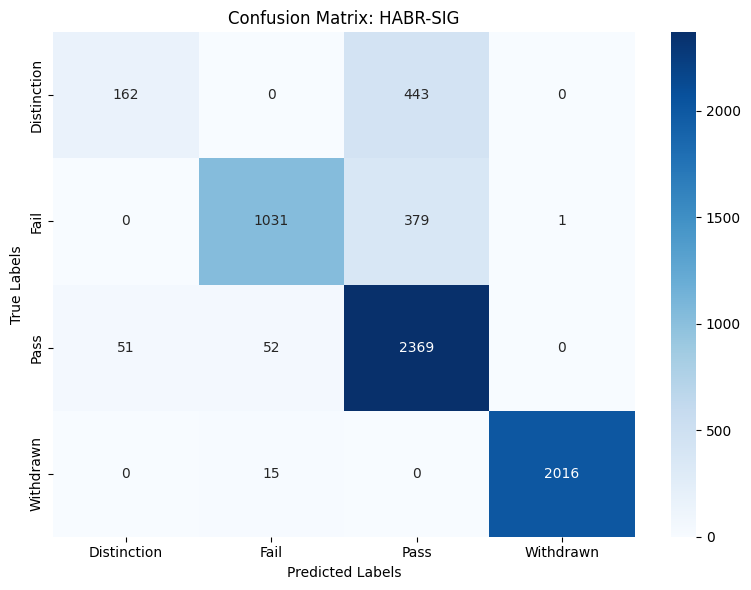

,IF,THEN,CF,confidence,support
571,has_unregistered is 1 [partition 0] AND assess...,Withdrawn,1.000000,1.000000,0.108383
557,has_unregistered is 1 [partition 0] AND tool_s...,Withdrawn,1.000000,1.000000,0.114420
556,has_unregistered is 1 [partition 0] AND code_p...,Withdrawn,1.000000,1.000000,0.114482
205,has_unregistered is Vc- [partition 0] AND aver...,Fail,1.000000,1.000000,0.016171
191,has_unregistered is 0 [partition 0] AND averag...,Fail,1.000000,1.000000,0.022791
517,num_of_prev_attempts is 0 [partition 0] AND ha...,Withdrawn,0.998527,0.999263,0.131584
508,has_unregistered is 1 [partition 0] AND highes...,Withdrawn,0.998356,0.999178,0.139833
512,has_unregistered is 1 [partition 0] AND conten...,Withdrawn,0.998351,0.999176,0.137550
511,has_unregistered is 1 [partition 0] AND naviga...,Withdrawn,0.998347,0.999173,0.137879
551,num_of_prev_attempts is 0 [partition 0] AND ha...,Withdrawn,0.998264,0.999132,0.115636



Tối ưu HABR-MUL
Validation accuracy: 0.8502396931927133 | Selected rules: 568 | Conditions: 1582

Model: HABR-MUL
              precision    recall  f1-score   support

 Distinction       0.79      0.28      0.42       605
        Fail       0.88      0.78      0.83      1411
        Pass       0.76      0.93      0.83      2472
   Withdrawn       1.00      0.99      1.00      2031

    accuracy                           0.86      6519
   macro avg       0.86      0.75      0.77      6519
weighted avg       0.86      0.86      0.84      6519



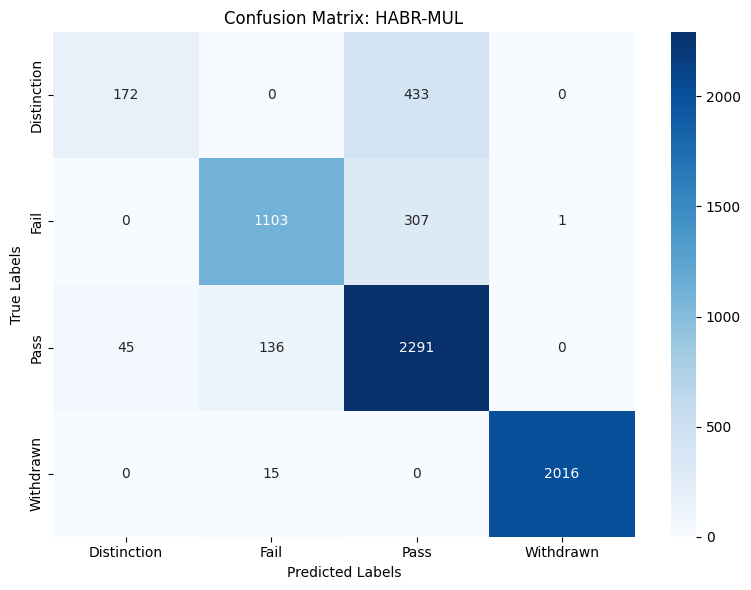

,IF,THEN,CF,confidence,support
555,num_of_prev_attempts is 0 [partition 0] AND ha...,Withdrawn,0.998093,0.999046,0.218723
528,num_of_prev_attempts is 0 [partition 0] AND ha...,Withdrawn,0.998082,0.999041,0.229801
465,num_of_prev_attempts is 0 [partition 0] AND ha...,Withdrawn,0.998082,0.999041,0.278637
466,num_of_prev_attempts is 0 [partition 0] AND ha...,Withdrawn,0.998081,0.999041,0.275622
467,num_of_prev_attempts is 0 [partition 0] AND ha...,Withdrawn,0.998077,0.999038,0.275008
468,num_of_prev_attempts is 0 [partition 0] AND ha...,Withdrawn,0.998053,0.999026,0.272826
442,num_of_prev_attempts is 0 [partition 0] AND ha...,Withdrawn,0.998053,0.999026,0.290944
565,num_of_prev_attempts is 0 [partition 0] AND da...,Withdrawn,0.998035,0.999018,0.227538
490,num_of_prev_attempts is 0 [partition 0] AND ha...,Withdrawn,0.998031,0.999015,0.260367
532,has_unregistered is 1 [partition 0] AND intera...,Withdrawn,0.998028,0.999014,0.227129


In [5]:
def dominates(a, b):
    return np.all(a <= b) and np.any(a < b)


def mopso(objective, dimension, generations, initial=None):
    local_rng = np.random.default_rng(SEED)
    position = local_rng.random((PSO_POP, dimension))
    if initial is not None:
        position[0] = initial
    velocity = np.zeros_like(position)
    pbest = position.copy()
    pvalue = np.array([objective(p) for p in position])
    archive = []
    history = []

    def update_archive(points, values):
        nonlocal archive
        candidates = archive + [(p.copy(), v.copy()) for p,v in zip(points, values)]
        unique = {}
        for p,v in candidates:
            key = tuple(v)
            unique.setdefault(key, (p,v))
        candidates = list(unique.values())
        archive = [(p,v) for p,v in candidates
                   if not any(dominates(w,v) for q,w in candidates)]
        # Bảo toàn hai cực accuracy/complexity, lấy mẫu nếu archive quá lớn.
        archive.sort(key=lambda item:tuple(item[1]))
        if len(archive) > 40:
            indices = np.linspace(0, len(archive)-1, 40).astype(int)
            archive = [archive[i] for i in indices]

    update_archive(position, pvalue)
    for gen in range(generations):
        leaders = np.array([archive[local_rng.integers(len(archive))][0] for _ in position])
        velocity = (.4*velocity + .2*local_rng.random(position.shape)*(pbest-position)
                    + .2*local_rng.random(position.shape)*(leaders-position))
        position = np.clip(position+velocity, 0, 1)
        values = np.array([objective(p) for p in position])
        for i in range(PSO_POP):
            if dominates(values[i], pvalue[i]) or (
                not dominates(pvalue[i], values[i]) and local_rng.random() < .5):
                pbest[i], pvalue[i] = position[i].copy(), values[i].copy()
        update_archive(position, values)
        best = min(archive, key=lambda item:tuple(item[1]))
        history.append(best[1].copy())
    return min(archive, key=lambda item:tuple(item[1]))[0], np.array(history), archive


def semantic_decode(p):
    n = len(num_cols)
    return .2+.6*p[:n], .2+.6*p[n:2*n], np.rint(3*p[2*n:]).astype(int)


def cat_data(indices):
    return X.iloc[indices][cat_cols].fillna('__MISSING__').astype(str).reset_index(drop=True)

cat_fit, cat_val, cat_train, cat_test = map(cat_data, [fit_idx, val_idx, train_idx, test_idx])
N_fit, N_val = A_fit[:,:len(num_cols)], A_val[:,:len(num_cols)]
N_train, N_test = A_train[:,:len(num_cols)], A_test[:,:len(num_cols)]


def recalibrate_selected(model, numeric, categorical, truth):
    # Giữ antecedent đã chọn; refit confidence/support/CF trên toàn bộ 80% train.
    E = model.build_atoms(numeric, categorical)
    selected = [r for r,a in zip(model.rules_,model.active_) if a]
    updated = []
    for r in selected:
        grade = np.prod(E[:,r['atoms']], axis=1)
        masses = np.array([grade[truth == c].sum(dtype=np.float64) for c in labels])
        if masses.sum() <= 1e-12:
            continue
        confidence = masses/masses.sum()
        cls = int(confidence.argmax())
        cf = np.sort(confidence)[-1]-np.sort(confidence)[-2]
        if cf > 1e-12:
            updated.append({**r, 'class':cls, 'CF':cf, 'confidence':confidence[cls],
                            'support':masses[cls]/len(truth)})
    model.rules_ = updated
    model.active_ = np.ones(len(updated), dtype=bool)
    model.default_ = np.bincount(truth, minlength=len(labels)).argmax()
    if not updated:
        raise ValueError('Không còn luật sau refit.')
    return model

habr_models, optimization_history = {}, {}
for granularity in ['SIG', 'MUL']:
    print('\nTối ưu HABR-' + granularity)
    cache = {}
    initial = np.r_[np.full(2*len(num_cols), .5), np.full(len(num_cols), 2/3)]
    def semantic_objective(p):
        theta, alpha, k = semantic_decode(p)
        key = tuple(np.round(np.r_[theta,alpha,k], 6))
        if key not in cache:
            model = HABR(theta,alpha,k,granularity).fit(
                N_fit,cat_fit,y[fit_idx],max_length=1,
                per_class=max(1, int(np.ceil(X.shape[1]/len(labels)))), beam=BEAM_PER_CLASS)
            pred = model.predict(N_val,cat_val)
            cache[key] = np.array([1-accuracy_score(y[val_idx],pred), len(model.rules_)], dtype=float)
        return cache[key]
    best_semantic, sem_history, _ = mopso(semantic_objective, len(initial), SEM_GEN, initial)
    theta, alpha, k = semantic_decode(best_semantic)
    candidate = HABR(theta,alpha,k,granularity).fit(
        N_fit,cat_fit,y[fit_idx],MAX_RULE_LENGTH,RULES_PER_CLASS,BEAM_PER_CLASS)
    scores = candidate.rule_scores(N_val,cat_val)
    lengths = np.array([len(r['atoms']) for r in candidate.rules_])
    def rule_objective(p):
        mask = p >= .5
        if not mask.any():
            return np.array([1., 0.])
        pred = candidate.predict_scores(scores,mask)
        return np.array([1-accuracy_score(y[val_idx],pred), lengths[mask].sum()], dtype=float)
    best_mask, rule_history, _ = mopso(rule_objective,len(candidate.rules_),RULE_GEN,
                                      np.ones(len(candidate.rules_)))
    candidate.active_ = best_mask >= .5
    if not candidate.active_.any():
        raise ValueError('MOPSO chọn tập luật rỗng.')
    print('Validation accuracy:', 1-rule_objective(best_mask)[0],
          '| Selected rules:', int(candidate.active_.sum()),
          '| Conditions:', int(lengths[candidate.active_].sum()))
    final_model = recalibrate_selected(candidate,N_train,cat_train,y[train_idx])
    name = 'HABR-' + granularity
    habr_models[name] = final_model
    optimization_history[name] = (sem_history,rule_history)
    evaluate(name,final_model.predict(N_test,cat_test))
    display(final_model.rule_table().sort_values('CF',ascending=False).head(10))


## 3. Phân loại bằng luật mờ theo ví dụ DOCX

Pipeline: chọn 3 nhóm click có mutual information cao trên tập fit → chuẩn hóa MinMax bằng tập fit → dùng SQM của Hedge Algebra để tạo 5 tâm `VeryLow`, `Low`, `Medium`, `High`, `VeryHigh` → lượng tử hóa các mẫu train → sinh luật dài tối đa 3 điều kiện → tính support và confidence → rút gọn luật → phân loại bằng độ kích hoạt mờ.

OULAD có 4 lớp `Distinction`, `Fail`, `Pass`, `Withdrawn`, nên giữ nguyên 4 nhãn thay cho hai nhãn `Good`/`AtRisk` trong ví dụ minh họa. Chỉ dùng các cột `*_sum_click`; không suy diễn thời gian học hoặc điểm quiz từ click. Các tham số số luật/ngưỡng được chọn bằng validation. Sau đó fit lại trên toàn bộ train và chỉ đánh giá test một lần. Độ kích hoạt của một luật là `min` mức thuộc các điều kiện; điểm lớp là `max(activation × confidence)` của các luật dẫn tới lớp đó.

In [6]:
from itertools import product
from sklearn.feature_selection import mutual_info_classif

click_cols = [c for c in X.columns if c.endswith('_sum_click')]
if len(click_cols) < 3:
    raise ValueError('Cần ít nhất 3 cột *_sum_click để tạo luật theo DOCX.')

def select_click_features(indices, n_features=3):
    data = X.iloc[indices][click_cols].apply(pd.to_numeric, errors='coerce')
    medians = data.median().fillna(0)
    scores = mutual_info_classif(data.fillna(medians), y[indices], random_state=SEED)
    ranking = sorted(zip(click_cols, scores), key=lambda item: (-item[1], item[0]))
    return [name for name, _ in ranking[:n_features]]

def click_arrays(train, other, columns):
    train_data = X.iloc[train][columns].apply(pd.to_numeric, errors='coerce')
    other_data = X.iloc[other][columns].apply(pd.to_numeric, errors='coerce')
    medians = train_data.median().fillna(0)
    scaler = MinMaxScaler(clip=True)
    a = scaler.fit_transform(train_data.fillna(medians))
    b = scaler.transform(other_data.fillna(medians))
    return a, b

fit_click_cols = select_click_features(fit_idx)
C_fit, C_val = click_arrays(fit_idx, val_idx, fit_click_cols)
print('Các thuộc tính click được chọn trên tập fit:', fit_click_cols)

Các thuộc tính click được chọn trên tập fit: ['navigation_pages_sum_click', 'interaction_and_discussion_sum_click', 'content_resource_sum_click']


Validation macro F1=0.1573; min_support=0.005; max_rules_per_class=80
SQM centers: {'VeryLow': np.float64(0.125), 'Low': np.float64(0.25), 'Medium': np.float64(0.5), 'High': np.float64(0.75), 'VeryHigh': np.float64(0.875)}
Số luật: 26


,IF,THEN,support,class_support,confidence,matched_train
0,navigation_pages_sum_click is VeryLow AND inte...,Withdrawn,0.9451,0.3107,0.3287,24642
1,navigation_pages_sum_click is VeryLow AND inte...,Withdrawn,0.9453,0.3107,0.3287,24648
2,interaction_and_discussion_sum_click is VeryLo...,Withdrawn,0.9482,0.3108,0.3278,24723
3,interaction_and_discussion_sum_click is VeryLow,Withdrawn,0.9486,0.3108,0.3277,24733
4,navigation_pages_sum_click is VeryLow AND cont...,Withdrawn,0.9863,0.3113,0.3157,25716
5,navigation_pages_sum_click is VeryLow,Withdrawn,0.9865,0.3113,0.3156,25723
6,content_resource_sum_click is VeryLow,Withdrawn,0.9995,0.3116,0.3118,26061
7,navigation_pages_sum_click is VeryLow AND inte...,Fail,0.9451,0.2140,0.2264,24642
8,interaction_and_discussion_sum_click is VeryLo...,Fail,0.9482,0.2144,0.2261,24723
9,interaction_and_discussion_sum_click is VeryLow,Fail,0.9486,0.2144,0.2260,24733



Model: HA-Fuzzy-Rules
              precision    recall  f1-score   support

 Distinction       0.00      0.00      0.00       605
        Fail       0.00      0.00      0.00      1411
        Pass       0.65      0.09      0.16      2472
   Withdrawn       0.33      1.00      0.49      2031

    accuracy                           0.35      6519
   macro avg       0.24      0.27      0.16      6519
weighted avg       0.35      0.35      0.22      6519



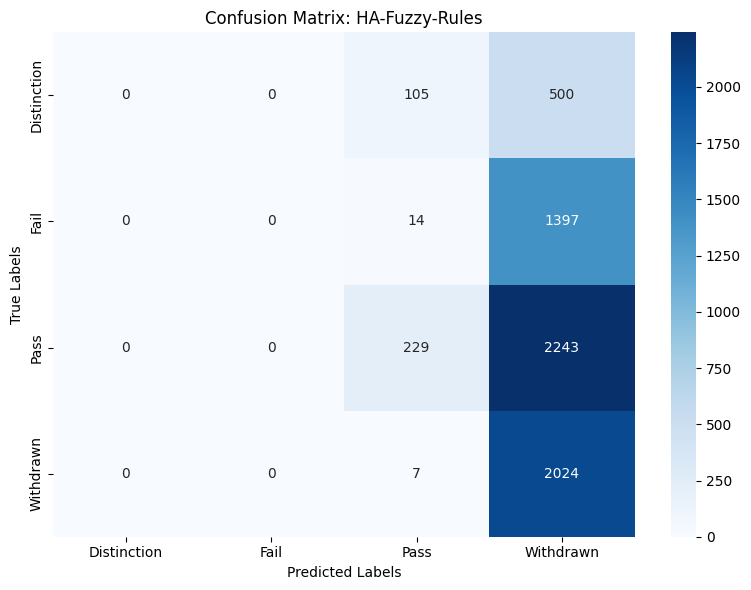

In [7]:
class HARuleClassifier:
    """SQM Hedge Algebra + luật crisp khi học, fuzzy khi dự đoán."""
    term_names = ('VeryLow', 'Low', 'Medium', 'High', 'VeryHigh')

    def __init__(self, columns, min_support=0.005, max_rules_per_class=40,
                 max_length=3, theta=0.5, alpha=0.5):
        self.columns = list(columns)
        self.min_support = min_support
        self.max_rules_per_class = max_rules_per_class
        self.max_length = max_length
        parts = sqm_partitions(theta, alpha, 2)
        base, hedged = dict(parts[1]), dict(parts[2])
        self.centers_ = np.array([hedged['Vc-'], base['c-'], theta,
                                  base['c+'], hedged['Vc+']], dtype=float)
        assert np.all(np.diff(self.centers_) > 0)

    def memberships(self, values):
        values = np.asarray(values, dtype=float)
        out = np.zeros((*values.shape, 5), dtype=float)
        centers = self.centers_
        out[..., 0] = np.clip((centers[1]-values)/(centers[1]-centers[0]), 0, 1)
        out[..., -1] = np.clip((values-centers[-2])/(centers[-1]-centers[-2]), 0, 1)
        for level in range(1, 4):
            left = (values-centers[level-1])/(centers[level]-centers[level-1])
            right = (centers[level+1]-values)/(centers[level+1]-centers[level])
            out[..., level] = np.maximum(0, np.minimum(left, right))
        return out

    def fit(self, values, truth):
        values, truth = np.asarray(values), np.asarray(truth)
        if values.shape[1] != len(self.columns):
            raise ValueError('Số cột dữ liệu không khớp với tên thuộc tính.')
        linguistic = self.memberships(values).argmax(axis=2)
        self.prior_ = np.bincount(truth, minlength=len(labels))/len(truth)
        self.default_ = int(self.prior_.argmax())
        candidates = []
        for length in range(1, min(self.max_length, len(self.columns))+1):
            for features in combinations(range(len(self.columns)), length):
                for terms in product(range(5), repeat=length):
                    matched = np.all(linguistic[:, features] == terms, axis=1)
                    n = int(matched.sum())
                    if n < max(2, int(np.ceil(self.min_support*len(truth)))):
                        continue
                    counts = np.bincount(truth[matched], minlength=len(labels))
                    for cls in labels:
                        confidence = counts[cls]/n
                        if counts[cls] < 2 or confidence <= self.prior_[cls]:
                            continue
                        candidates.append({'features': features, 'terms': terms,
                                           'class': int(cls), 'support': n/len(truth),
                                           'class_support': counts[cls]/len(truth),
                                           'confidence': confidence, 'count': n})
        candidates.sort(key=lambda r: (-r['confidence']*r['class_support'],
                                       len(r['features']), r['features'], r['terms']))
        self.rules_ = []
        per_class = np.zeros(len(labels), dtype=int)
        for rule in candidates:
            cls = rule['class']
            if per_class[cls] >= self.max_rules_per_class:
                continue
            conditions = set(zip(rule['features'], rule['terms']))
            redundant = any(old['class'] == cls and
                            set(zip(old['features'], old['terms'])).issubset(conditions) and
                            old['confidence'] >= rule['confidence']
                            for old in self.rules_)
            if not redundant:
                self.rules_.append(rule)
                per_class[cls] += 1
        if not self.rules_:
            raise ValueError('Không sinh được luật; giảm ngưỡng support.')
        return self

    def predict(self, values):
        membership = self.memberships(values)
        scores = np.zeros((len(values), len(labels)))
        for rule in self.rules_:
            activation = np.min(membership[:, rule['features'], rule['terms']], axis=1)
            cls = rule['class']
            scores[:, cls] = np.maximum(scores[:, cls], activation*rule['confidence'])
        pred = scores.argmax(axis=1)
        pred[scores.max(axis=1) == 0] = self.default_
        return pred

    def rule_table(self):
        return pd.DataFrame([{
            'IF': ' AND '.join(f'{self.columns[j]} is {self.term_names[t]}'
                               for j, t in zip(rule['features'], rule['terms'])),
            'THEN': target_names[rule['class']],
            'support': rule['support'],
            'class_support': rule['class_support'],
            'confidence': rule['confidence'],
            'matched_train': rule['count']
        } for rule in self.rules_])


# Chọn độ hỗ trợ và giới hạn số luật trên validation, không nhìn test.
tuning = []
for support in (0.005, 0.01, 0.02):
    for limit in (20, 40, 80):
        model = HARuleClassifier(fit_click_cols, support, limit).fit(C_fit, y[fit_idx])
        pred = model.predict(C_val)
        tuning.append((f1_score(y[val_idx], pred, average='macro', zero_division=0),
                       -len(model.rules_), support, limit))
best_f1, _, best_support, best_limit = max(tuning)
print(f'Validation macro F1={best_f1:.4f}; min_support={best_support}; '
      f'max_rules_per_class={best_limit}')

final_click_cols = select_click_features(train_idx)
C_train, C_test = click_arrays(train_idx, test_idx, final_click_cols)
ha_rules = HARuleClassifier(final_click_cols, best_support, best_limit).fit(
    C_train, y[train_idx])
print('SQM centers:', dict(zip(ha_rules.term_names, ha_rules.centers_.round(3))))
print('Số luật:', len(ha_rules.rules_))
display(ha_rules.rule_table().head(15).round(4))
evaluate('HA-Fuzzy-Rules', ha_rules.predict(C_test))

## 4. So sánh kết quả
Mọi mô hình được đánh giá trên cùng 20% test, giữ nguyên bốn lớp trong final_result. Macro F1 giúp xem hiệu quả giữa các lớp khi phân bố mất cân bằng; không dùng bảng test này để tiếp tục chỉnh tham số.


In [8]:
comparison = pd.DataFrame(results).set_index('Model')
display(comparison.round(4))
assert set(predictions) == {'K-means','FCM','HA-FCM','HABR-SIG','HABR-MUL','HA-Fuzzy-Rules'}
assert all(len(p) == len(test_idx) for p in predictions.values())
assert all(np.isin(p,labels).all() for p in predictions.values())
print('Hoàn tất đánh giá 6 mô hình trên cùng tập test.')


,Accuracy,Macro F1,Weighted F1
Model,,,
K-means,0.6792,0.6652,0.6994
FCM,0.7050,0.6879,0.7256
HA-FCM,0.8079,0.7380,0.8075
HABR-SIG,0.8557,0.7627,0.8422
HABR-MUL,0.8563,0.7687,0.8441
HA-Fuzzy-Rules,0.3456,0.1640,0.2153


Hoàn tất đánh giá 6 mô hình trên cùng tập test.


In [9]:
# Kiểm tra công thức: SQM, độ gần rational, khoảng HA và membership.
p = sqm_partitions(.5, .5, 2)
assert np.allclose([v for name,v in p[1] if name in ('c-','c+')], [.25,.75])
values = dict(p[2])
assert np.allclose([values[t] for t in ['Vc-','Lc-','Lc+','Vc+']], [.125,.375,.625,.875])
eta = ha_closeness(np.array([.2,.25,.3,.8]), np.array([0.,.25,.5]), 1)
assert np.allclose(eta, [5/6,1.,5/6,0.])
centers = np.array([[0.,0.],[2.,0.]])
sample = np.array([[0.,0.],[1.,0.],[2.,0.]])
radii = np.array([2.,2.])
fcm = FuzzyCMeans(2)
ha = FuzzyCMeans(2,ha=True,w=.5,mu=[.25]*4)
u = fcm.memberships(sample,centers,radii)
assert np.allclose(ha.widths.sum(),1.)
assert np.allclose(u.sum(axis=1),1.)
assert np.allclose(u, [[1.,0.],[.5,.5],[0.,1.]])
# Với độ dài khoảng bằng nhau, cập nhật membership HA trùng FCM.
assert np.allclose(u,ha.memberships(sample,centers,radii))
assert np.allclose(ha.memberships(sample[:1],centers,radii),
                   ha.memberships(sample,centers,radii)[:1])
print('Kiểm tra công thức SQM, độ gần HA và membership: PASS')

# Kiểm tra đường đi từ dữ liệu ngôn ngữ đến dự đoán cho hai lớp hiện diện.
tiny_x = np.array([[.05,.10,.08], [.10,.06,.11], [.07,.12,.09], [.08,.08,.10],
                   [.90,.92,.88], [.94,.87,.91], [.88,.89,.93], [.91,.95,.90]])
tiny_y = np.array([0,0,0,0,1,1,1,1])
tiny = HARuleClassifier(['click_a','click_b','click_c'], min_support=.1,
                        max_rules_per_class=10).fit(tiny_x,tiny_y)
assert np.array_equal(tiny.predict(tiny_x),tiny_y)
assert all(0 < r['support'] <= 1 and 0 < r['confidence'] <= 1 for r in tiny.rules_)
print('Kiểm tra pipeline luật mờ: PASS')

Kiểm tra công thức SQM, độ gần HA và membership: PASS
Kiểm tra pipeline luật mờ: PASS
